In [49]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [50]:
athletes = pd.read_csv ("..//data/raw/athlete_events.csv")
regions = pd.read_csv ("..//data/raw/noc_regions.csv")

In [51]:
athletes.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [52]:
regions.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


## Data cleaning and Transformation

Here, we clean and transform the 120 years of Olymics athlete datasey by merging related tables, filtering the years, renaming the columns, converting measurment units, and preparing the data for analysis 


In [53]:
athletes.shape, regions.shape 

((271116, 15), (230, 3))

In [54]:
athletes.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 31.0 MB


In [55]:
regions.info()

<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NOC     230 non-null    str  
 1   region  227 non-null    str  
 2   notes   21 non-null     str  
dtypes: str(3)
memory usage: 5.5 KB


## Data Inspection

We first inspect the size, structure, and data types of both datasers to understadn their contents and identify issues such as missing values or mismatched columns before merging.

In [56]:
df = pd.merge(athletes, regions, on="NOC", how="left")

In [57]:
df.shape

(271116, 17)

In [58]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [59]:
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

## Data Merging

The athlete dataset was merged with the NOC regions dataset using the `NOC` column as the key. A left join was used to retain all athlete records while appending regional information where available.

In [60]:
df.shape
df.head()
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

In [61]:
df = df.rename(columns={
    "Weight": "Weight_kg",
    "Height": "Height_cm"
})

In [62]:
df["Weight_lbs"] = (df["Weight_kg"] * 2.20462).round()
df["Height_in"] = (df["Height_cm"] * 0.393701).round()

In [63]:
df = df[(df["Year"] >= 1996) & (df["Year"] <= 2016)]

In [64]:
df.shape 
df.head()

,ID,Name,Sex,Age,Height_cm,Weight_kg,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Weight_lbs,Height_in
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,132.0,67.0
28,9,Antti Sami Aalto,M,26.0,186.0,96.0,Finland,FIN,2002 Winter,2002,Winter,Salt Lake City,Ice Hockey,Ice Hockey Men's Ice Hockey,NaN,Finland,NaN,212.0,73.0
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN,Finland,NaN,154.0,68.0
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,122.0,63.0
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,122.0,63.0


## Data Transformation

This dataset was transformed by renaming measurement columns to reflect their units, converting weight and height into alternative units (pounds and inches), and filtering the dataset to include Olympic events between 1996 and 2016.

In [65]:
df["Medal"] = df["Medal"].fillna("No Medal")

Missing values in the Medal column were replaced with "No Medal" since missing values indicate that the athlete did not win a medal.

In [66]:
df = df.drop(columns=["notes"])

The notes column was dropped due to a high proportion of missing values, making it unsuitable for meaningful analysis.

In [67]:
df["region"] = df["region"].fillna("Unknown")

Missing values in the region column were filled with "Unknown" since the number of missing entries was minimal.

In [68]:
df[["Age", "Height_cm", "Weight_kg"]].describe()

,Age,Height_cm,Weight_kg
count,102630.000000,99977.000000,99526.000000
mean,25.687314,175.794223,71.097383
std,5.436733,10.995916,15.305417
min,12.000000,133.000000,28.000000
25%,22.000000,168.000000,60.000000
50%,25.000000,176.000000,70.000000
75%,29.000000,183.000000,80.000000
max,71.000000,226.000000,214.000000


In [69]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Height_cm"] = df["Height_cm"].fillna(df["Height_cm"].median())
df["Weight_kg"] = df["Weight_kg"].fillna(df["Weight_kg"].median())

df["Height_cm"] = df["Height_cm"].fillna(
    df.groupby("Sex")["Height_cm"].transform("median")
).fillna(df["Height_cm"].median())

df["Weight_kg"] = df["Weight_kg"].fillna(
    df.groupby("Sex")["Weight_kg"].transform("median")
).fillna(df["Weight_kg"].median())

In [70]:
df["Weight_lbs"] = (df["Weight_kg"] * 2.20462).round()
df["Height_in"] = (df["Height_cm"] * 0.393701).round()

Missing values in Age, Height, and Weight were replaced using the median of each column. Median imputation was chosen to reduce the impact of outliers and preserve the distribution of the data. For Height and Weight, median values were calculated separately for men and women.

In [71]:
df.isna().sum()

ID            0
Name          0
Sex           0
Age           0
Height_cm     0
Weight_kg     0
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
region        0
Weight_lbs    0
Height_in     0
dtype: int64

In [72]:
df["region"] = df["region"].fillna("Unknown")

In [73]:
df.isna().sum()

ID            0
Name          0
Sex           0
Age           0
Height_cm     0
Weight_kg     0
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
region        0
Weight_lbs    0
Height_in     0
dtype: int64

Remaining missing values in the region column were filled with "Unknown" to ensure completeness of the dataset.

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
(df["Age"] < 0).sum()
(df["Height_cm"] <= 0).sum()
(df["Weight_kg"] <= 0).sum()

np.int64(0)

Some team names are near-duplicates (e.g. "France, France-1, France-2, France-3".) For our purposes these can be merged by removing non-alphabetic characters at the end of the string.

In [76]:
df["Team"] = df["Team"].str.replace(r"-\d+$", "", regex=True)

In [77]:
df["Has_Medal"] = df["Medal"].apply(lambda x: 0 if x == "No Medal" else 1)

In [78]:
df.head()

,ID,Name,Sex,Age,Height_cm,Weight_kg,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Weight_lbs,Height_in,Has_Medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,132.0,67.0,0
28,9,Antti Sami Aalto,M,26.0,186.0,96.0,Finland,FIN,2002 Winter,2002,Winter,Salt Lake City,Ice Hockey,Ice Hockey Men's Ice Hockey,No Medal,Finland,212.0,73.0,0
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,No Medal,Finland,154.0,68.0,0
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,No Medal,Finland,122.0,63.0,0
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,No Medal,Finland,122.0,63.0,0


In [79]:
df.to_csv("../data/cleaned/cleaned_olympics_data.csv", index=False)

## Exploratory Data Analysis

In [80]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 102643 entries, 1 to 271115
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          102643 non-null  int64  
 1   Name        102643 non-null  str    
 2   Sex         102643 non-null  str    
 3   Age         102643 non-null  float64
 4   Height_cm   102643 non-null  float64
 5   Weight_kg   102643 non-null  float64
 6   Team        102643 non-null  str    
 7   NOC         102643 non-null  str    
 8   Games       102643 non-null  str    
 9   Year        102643 non-null  int64  
 10  Season      102643 non-null  str    
 11  City        102643 non-null  str    
 12  Sport       102643 non-null  str    
 13  Event       102643 non-null  str    
 14  Medal       102643 non-null  str    
 15  region      102643 non-null  str    
 16  Weight_lbs  102643 non-null  float64
 17  Height_in   102643 non-null  float64
 18  Has_Medal   102643 non-null  int64  
dtypes: float64(5), int

,ID,Age,Height_cm,Weight_kg,Year,Weight_lbs,Height_in,Has_Medal
count,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000
mean,68977.641836,25.687227,175.799567,71.064059,2006.053116,156.633224,69.231911,0.140487
std,39141.008416,5.436394,10.852223,15.072406,6.619310,33.226379,4.277489,0.347493
min,2.000000,12.000000,133.000000,28.000000,1996.000000,62.000000,52.000000,0.000000
25%,35476.500000,22.000000,168.000000,60.000000,2000.000000,132.000000,66.000000,0.000000
50%,69173.000000,25.000000,176.000000,70.000000,2006.000000,154.000000,69.000000,0.000000
75%,102725.500000,29.000000,183.000000,80.000000,2012.000000,176.000000,72.000000,0.000000
max,135571.000000,71.000000,226.000000,214.000000,2016.000000,472.000000,89.000000,1.000000


### Histograms for all of the numeric colummns
For this, we are ignoring displaying the histograms for Height_cm and Weight_kg columns, as they are later translated to US Metrics

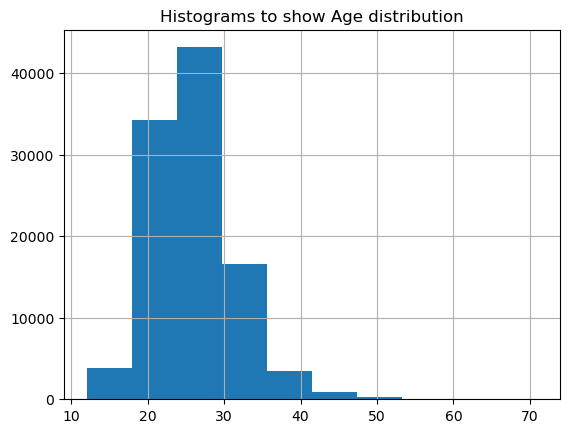

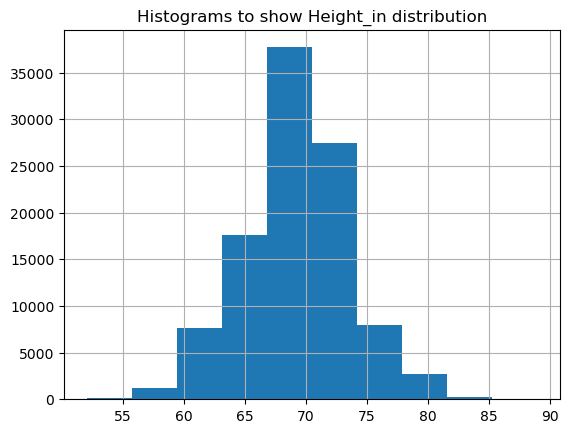

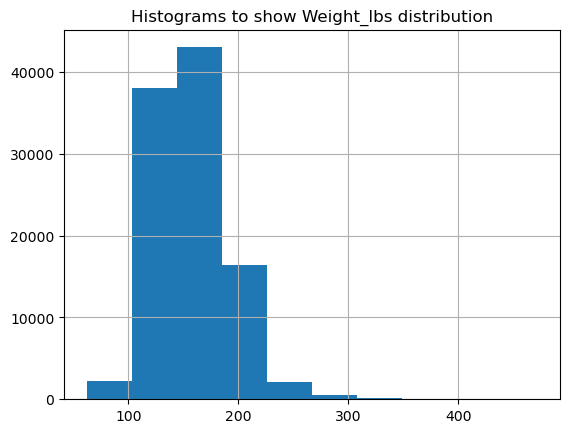

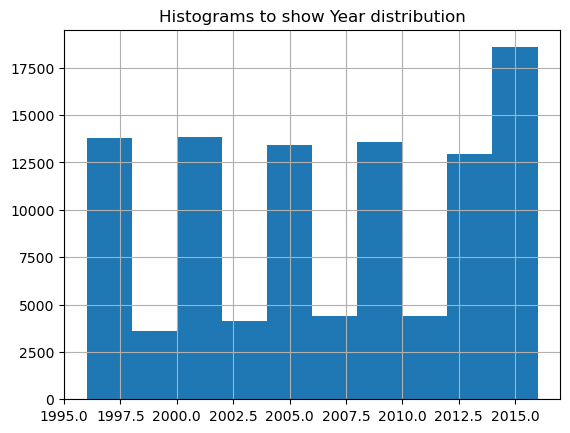

In [81]:
numeric_cols = ["Age", "Height_in", "Weight_lbs", "Year"]

for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Histograms to show {col} distribution")
    plt.show()

### Value counts for all of the categorical colummns


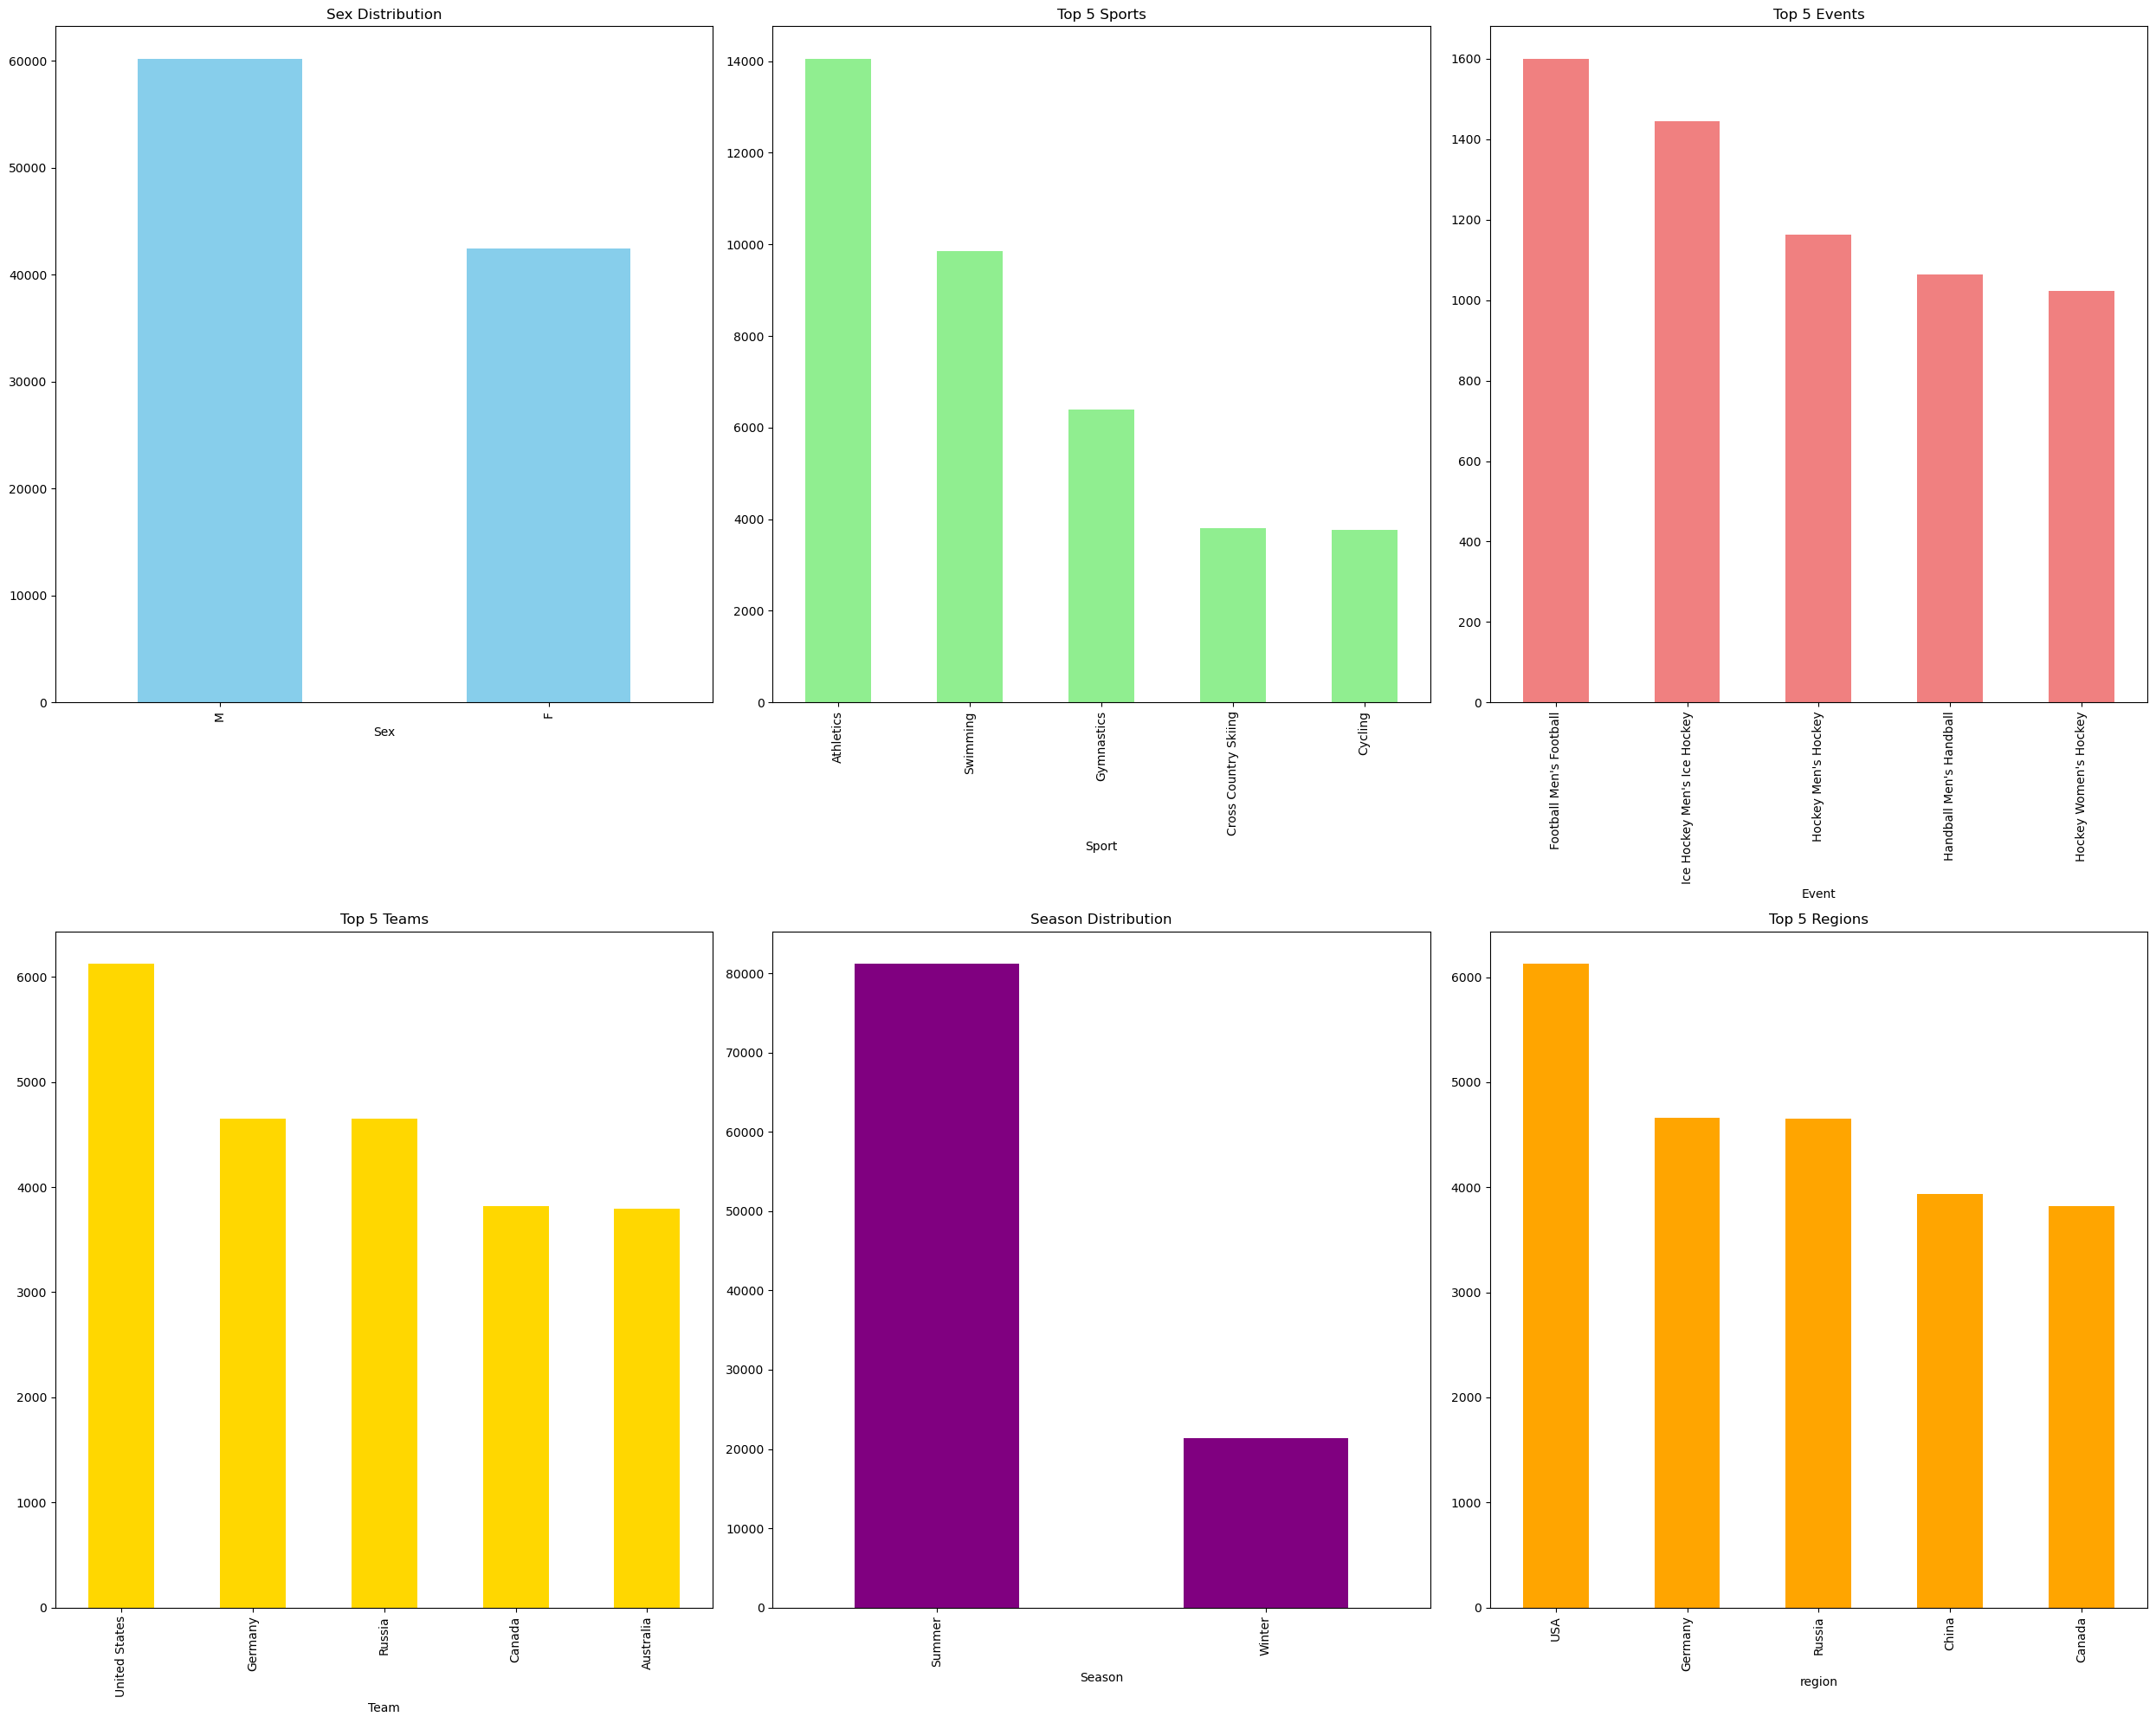

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(25, 20))

# Sex
df["Sex"].value_counts().plot(kind='bar', ax=axes[0,0], title='Sex Distribution', color='skyblue')

# Top 5 Sports
df["Sport"].value_counts().head().plot(kind='bar', ax=axes[0,1], title='Top 5 Sports', color='lightgreen')

# Top 5 Events
df["Event"].value_counts().head().plot(kind='bar', ax=axes[0,2], title='Top 5 Events', color='lightcoral')

# Top 5 Teams
df["Team"].value_counts().head().plot(kind='bar', ax=axes[1,0], title='Top 5 Teams', color='gold')

# Season
df["Season"].value_counts().plot(kind='bar', ax=axes[1,1], title='Season Distribution', color='purple')

# Top 5 Regions
df["region"].value_counts().head().plot(kind='bar', ax=axes[1,2], title='Top 5 Regions', color='orange')

plt.tight_layout()
plt.show()

### Identifying most popular sport by enrollment count

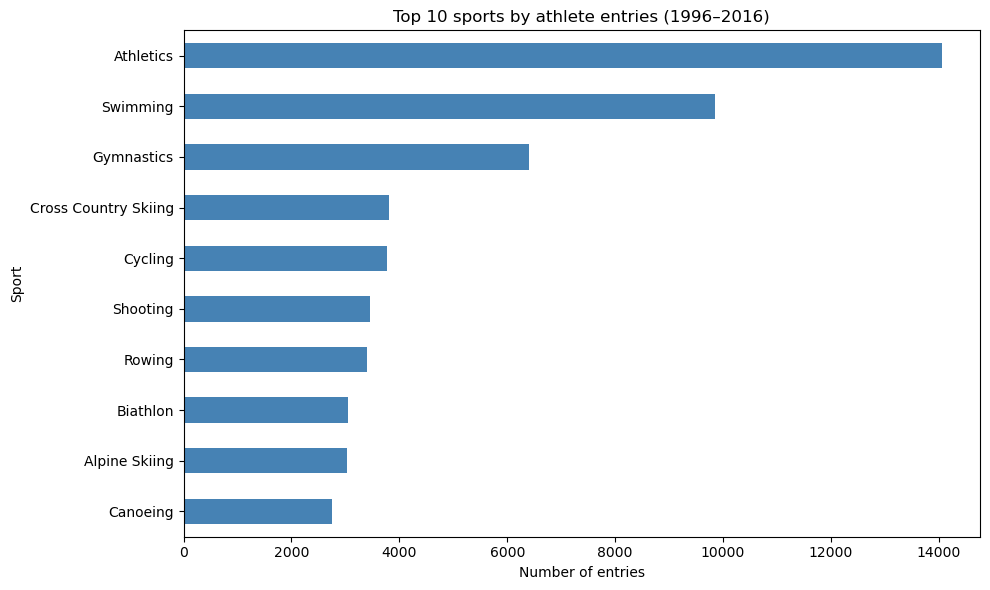

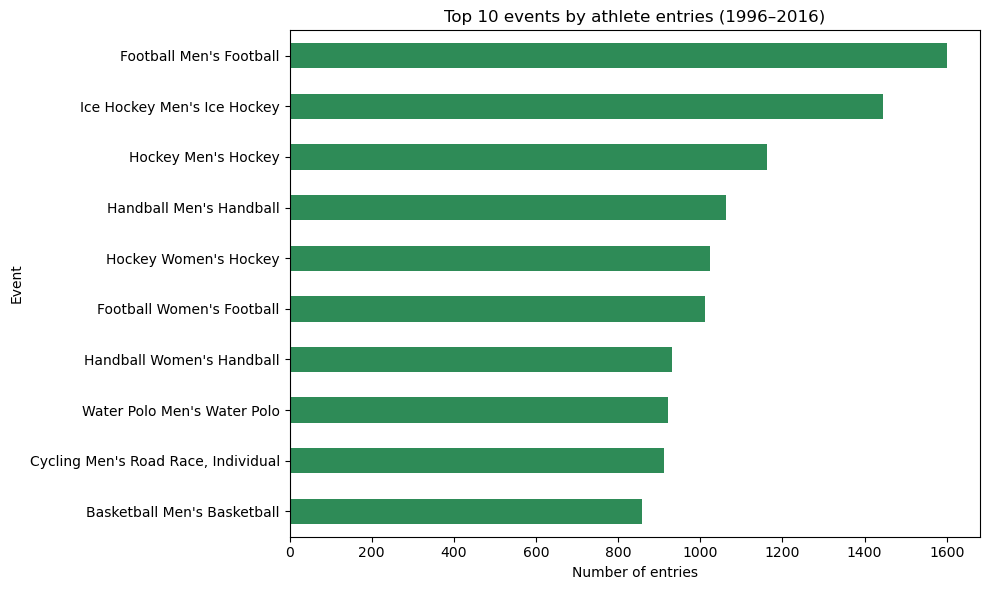

In [83]:
# Top 10 sports
top_sports = df["Sport"].value_counts().head(10)

top_sports.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 10 sports by athlete entries (1996–2016)")
plt.xlabel("Number of entries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 events
top_events = df["Event"].value_counts().head(10)

top_events.plot(kind="barh", figsize=(10, 6), color="seagreen")
plt.title("Top 10 events by athlete entries (1996–2016)")
plt.xlabel("Number of entries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Aggregations

We will perform aggregations on the data to learn more detailed information. We will include aggregations on all data, aggregations on groups, and pivot tables.

In [84]:
# How many total athletes competed in the Olympic Games from 1996-2016?

df["Name"].nunique()

52962

In [85]:
# How many different sporting events were there to compete in?

df["Sport"].nunique()

51

In [93]:
# Which teams have won the most total medals?

df.groupby("Team")["Has_Medal"] \
    .sum() \
    .reset_index(name="Total Medals") \
    .sort_values(by="Total Medals", ascending = False) \
    .reset_index(drop=True)

,Team,Total Medals
0,United States,1924
1,Russia,1112
2,Germany,989
3,Australia,828
4,China,775
...,...,...
238,Tuvalu,0
239,Whisper,0
240,Vanuatu,0
241,Yemen,0


In [88]:
# More detailed breakdown of medals for Summer Olympics

summer_pivot = df[
    (df["Season"] == "Summer") & (df["Medal"] != "No Medal")
].pivot_table(
    index=["Team"],
    columns="Medal",
    values="Name",
    aggfunc="count",
    fill_value=0
)

summer_pivot["Total"] = summer_pivot.sum(axis=1)
summer_pivot = summer_pivot[["Gold", "Silver", "Bronze", "Total"]]
summer_pivot = summer_pivot.sort_values(by="Total", ascending=False)

summer_pivot

Medal,Gold,Silver,Bronze,Total
Team,,,,
United States,817,405,371,1593
Russia,295,271,322,888
Australia,213,275,329,817
Germany,247,189,304,740
China,286,243,172,701
...,...,...,...,...
Sri Lanka,0,1,0,1
Togo,0,0,1,1
Tonga,0,1,0,1


In [113]:
# More detailed breakdown of medals for Winter Olympics

winter_pivot = df[
    (df["Season"] == "Winter") & (df["Medal"] != "No Medal")
].pivot_table(
    index=["Team"],
    columns="Medal",
    values="Name",
    aggfunc="count",
    fill_value=0
)

winter_pivot["Total"] = winter_pivot.sum(axis=1)
winter_pivot = winter_pivot[["Gold", "Silver", "Bronze", "Total"]]
winter_pivot = winter_pivot.sort_values(by="Total", ascending=False)

winter_pivot

Medal,Gold,Silver,Bronze,Total
Team,,,,
Canada,222,100,46,368
United States,67,166,98,331
Germany,101,96,52,249
Russia,75,76,73,224
Finland,11,54,127,192
Norway,72,54,53,179
Sweden,54,60,52,166
Austria,37,37,49,123
Switzerland,26,23,52,101


Medal,Gold,Silver,Bronze,Total
Sex,,,,
M,481,477,481,1439
F,378,372,372,1122


How many teams compete in each sport each year?

In [114]:
# summer

summer_teams_by_sport = df[
    (df["Season"] == "Summer")
].pivot_table(
    index=["Sport", "Year"],
    values="Team",
    aggfunc="nunique",
    fill_value=0
)

summer_teams_summary = summer_teams_by_sport.groupby("Sport").agg(
    Total_Teams=("Team", "sum"),
    Avg_Teams=("Team", "mean"),
    Min_Teams=("Team", "min"),
    Max_Teams=("Team", "max")
).sort_values(by="Total_Teams", ascending=False)

summer_teams_summary["Avg_Teams"] = summer_teams_summary["Avg_Teams"].round(2)

summer_teams_summary

,Total_Teams,Avg_Teams,Min_Teams,Max_Teams
Sport,,,,
Athletics,1180,196.67,190,201
Swimming,922,153.67,117,173
Judo,636,106.00,90,136
Shooting,617,102.83,97,108
Weightlifting,492,82.00,76,92
Boxing,474,79.00,72,97
Cycling,403,67.17,55,79
Sailing,399,66.50,61,78
Wrestling,391,65.17,55,75


In [111]:
# Winter

winter_teams_by_sport = df[
    (df["Season"] == "Winter")
].pivot_table(
    index=["Sport", "Year"],
    values="Team",
    aggfunc="nunique",
    fill_value=0
)

winter_teams_summary = winter_teams_by_sport.groupby("Sport").agg(
    Total_Teams=("Team", "sum"),
    Avg_Teams=("Team", "mean"),
    Min_Teams=("Team", "min"),
    Max_Teams=("Team", "max")
).sort_values(by="Total_Teams", ascending=False)

winter_teams_summary

,Total_Teams,Avg_Teams,Min_Teams,Max_Teams
Sport,,,,
Alpine Skiing,304,60.8,49,73
Cross Country Skiing,243,48.6,37,55
Biathlon,175,35.0,32,37
Figure Skating,164,32.8,30,37
Bobsleigh,130,26.0,22,34
Freestyle Skiing,125,25.0,21,30
Snowboarding,123,24.6,19,31
Luge,122,24.4,24,26
Short Track Speed Skating,116,23.2,18,26


How many men and women compete in each sport? Which sports are most popular for men and which for women?

In [128]:
summer_sports_by_sex = df[
    (df["Season"] == "Summer")
].pivot_table(
    index=["Sport"],
    columns="Sex",
    values="Name",
    aggfunc="count",
    fill_value=0
)

summer_sports_by_sex["Total"] = summer_sports_by_sex["F"] + summer_sports_by_sex["M"]
summer_sports_by_sex["M:F Ratio"] = summer_sports_by_sex["M"].div(
    summer_sports_by_sex["F"]
).round(2)
summer_sports_by_sex = summer_sports_by_sex.sort_values(by="M:F Ratio")
summer_sports_by_sex

Sex,F,M,Total,M:F Ratio
Sport,,,,
Softball,478,0,478,0.00
Synchronized Swimming,658,0,658,0.00
Rhythmic Gymnastics,544,0,544,0.00
Badminton,630,601,1231,0.95
Table Tennis,751,750,1501,1.00
Basketball,854,858,1712,1.00
Golf,60,60,120,1.00
Tennis,785,787,1572,1.00
Trampolining,76,76,152,1.00


In [129]:
winter_sports_by_sex = df[
    (df["Season"] == "Winter")
].pivot_table(
    index=["Sport"],
    columns="Sex",
    values="Name",
    aggfunc="count",
    fill_value=0
)

winter_sports_by_sex["Total"] = winter_sports_by_sex["F"] + winter_sports_by_sex["M"]
winter_sports_by_sex["M:F Ratio"] = winter_sports_by_sex["M"].div(
    winter_sports_by_sex["F"]
).round(2)
winter_sports_by_sex = winter_sports_by_sex.sort_values(by="M:F Ratio")
winter_sports_by_sex

Sex,F,M,Total,M:F Ratio
Sport,,,,
Figure Skating,400,402,802,1.00
Curling,222,225,447,1.01
Short Track Speed Skating,609,613,1222,1.01
Biathlon,1472,1572,3044,1.07
Speed Skating,853,927,1780,1.09
Freestyle Skiing,363,404,767,1.11
Cross Country Skiing,1759,2050,3809,1.17
Alpine Skiing,1346,1681,3027,1.25
Snowboarding,416,520,936,1.25
